### 1. Import các thư viện cần thiết

In [2]:
import pandas as pd
from pyvi import ViTokenizer

### 2. Đọc file dữ liệu và tiền xử lý cơ bản
Đọc file `train.csv`, điền các giá trị rỗng và chuẩn hóa chuỗi cơ bản.

In [2]:
df = pd.read_csv('train.csv')

# Điền phần tử bị thiếu và xóa khoảng trắng 2 đầu
df['title'] = df['title'].fillna('').astype(str).str.strip()
df['lead_paragraph'] = df['lead_paragraph'].fillna('').astype(str).str.strip()
df['label'] = df['label'].fillna('').astype(str).str.strip()

# Loại bỏ các dòng không có label hoặc hoàn toàn rỗng
df = df[df['label'] != ''].reset_index(drop=True)
df = df[(df['title'] != '') | (df['lead_paragraph'] != '')].reset_index(drop=True)

print(f"Tổng số dòng: {len(df)}")

Tổng số dòng: 2731


### 3. Mô phỏng quá trình Segmentation & Nối title với lead_paragraph
Dùng `ViTokenizer` cho tách từ và sử dụng `[SEP]` để nối phân cách giữa 2 trường.

In [3]:
sep_token = "[SEP]"
processed_texts = []

for idx, row in df.iterrows():
    t = row['title']
    l = row['lead_paragraph']
    
    # Segment tách từ phân âm tiết tiếng Việt
    t_seg = ViTokenizer.tokenize(t) if t else ""
    l_seg = ViTokenizer.tokenize(l) if l else ""
    
    # Nối dữ liệu
    if t_seg and l_seg:
        processed_texts.append(f"{t_seg} {sep_token} {l_seg}")
    elif t_seg:
        processed_texts.append(t_seg)
    else:
        processed_texts.append(l_seg)

# Tạo cột mới chứa text hoàn chỉnh
df['merged_text'] = processed_texts

### 4. Hiển thị mẫu kết quả Data sinh ra
Bao gồm Index và nội dung string hoàn chỉnh đã nối.

In [4]:
for idx, row in df.head(5).iterrows():
    print(f"Index            : {idx}")
    print(f"Raw Title        : {row['title']}")
    print(f"Raw Lead Para    : {row['lead_paragraph']}")
    print(f"Merged Text      : {row['merged_text']}")
    print(f"Label            : {row['label']}")
    print("-" * 80)

Index            : 0
Raw Title        : Kiên Giang gọi đầu tư loạt khu đô thị tỷ USD ở Phú Quốc
Raw Lead Para    : UBND tỉnh Kiên Giang vừa duyệt danh mục 40 dự án kêu gọi đầu tư, trong đó có nhiều khu đô thị tỷ USD phục vụ hội nghị APEC 2027.
Merged Text      : Kiên_Giang gọi đầu_tư loạt khu đô_thị tỷ USD ở Phú_Quốc [SEP] UBND tỉnh Kiên_Giang vừa duyệt danh_mục 40 dự_án kêu_gọi đầu_tư , trong đó có nhiều khu đô_thị tỷ USD phục_vụ hội_nghị APEC 2027 .
Label            : non-clickbait
--------------------------------------------------------------------------------
Index            : 1
Raw Title        : 'Cái chết của vua câm' - Báo Hà Nội Mới
Raw Lead Para    : Đọc tập truyện ngắn 'Cái chết của vua câm' của nhà văn, nhà báo Nguyễn Văn Học (NXB Văn học 2025), tôi thấy dường như nhà văn có xu hướng đi sâu vào hai mảng đề tài khá rõ nét.
Merged Text      : ' Cái chết của vua câm ' - Báo Hà_Nội Mới [SEP] Đọc tập truyện_ngắn ' Cái chết của vua câm ' của nhà_văn , nhà_báo Nguyễn Văn_Học ( NXB

### 5. Thống kê phân phối Label trong file 'validate.csv'

In [3]:
# Đọc file validate.csv
val_df = pd.read_csv('raw/clickbait_dataset_vietnamese.csv')

# Làm sạch data
val_df['label'] = val_df['label'].fillna('').astype(str).str.strip()

# Đếm số lượng từng label
label_counts = val_df['label'].value_counts()
label_total = len(val_df)

print("=" * 60)
print("THỐNG KÊ PHÂN PHỐI LABEL TRONG raw")
print("=" * 60)
print(f"\nTổng số dòng: {label_total}")
print(f"\nPhân phối label:")
print("-" * 60)

for label, count in label_counts.items():
    percentage = (count / label_total) * 100
    bar_length = int(percentage / 5)  # Mỗi ký tự # = 5%
    print(f"{label:15s} | {count:5d} ({percentage:6.2f}%) | {'#' * bar_length}")

print("-" * 60)
print(f"\nTỷ lệ phân cân:")
for label, count in label_counts.items():
    percentage = (count / label_total) * 100
    print(f"  {label}: {percentage:.2f}%")

THỐNG KÊ PHÂN PHỐI LABEL TRONG raw

Tổng số dòng: 3414

Phân phối label:
------------------------------------------------------------
non-clickbait   |  2349 ( 68.80%) | #############
clickbait       |  1065 ( 31.20%) | ######
------------------------------------------------------------

Tỷ lệ phân cân:
  non-clickbait: 68.80%
  clickbait: 31.20%


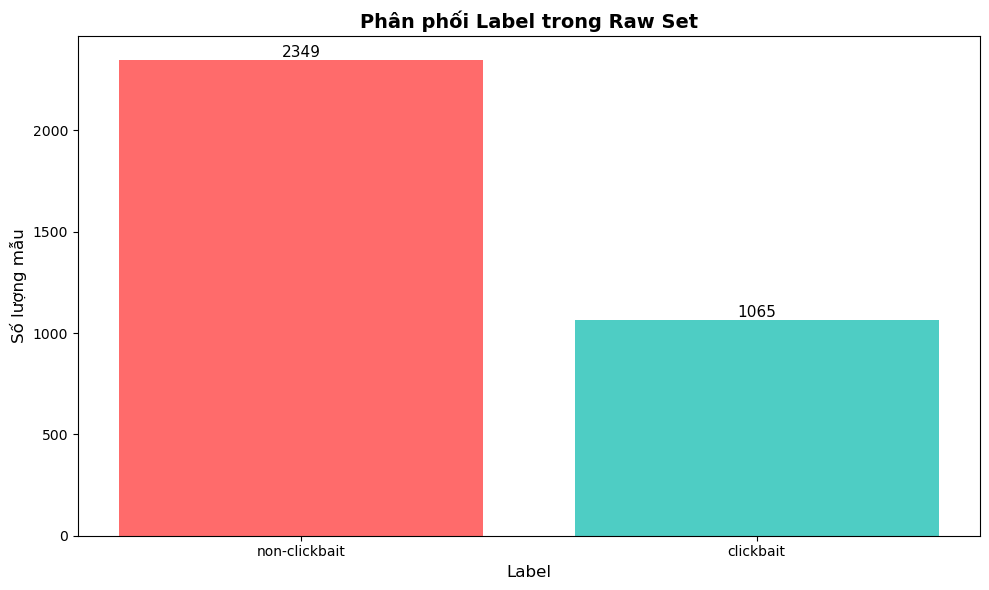

In [5]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ cột phân phối label
fig, ax = plt.subplots(figsize=(10, 6))
labels = label_counts.index.tolist()
values = label_counts.values.tolist()

bars = ax.bar(labels, values, color=['#FF6B6B', '#4ECDC4'])
ax.set_ylabel('Số lượng mẫu', fontsize=12)
ax.set_xlabel('Label', fontsize=12)
ax.set_title('Phân phối Label trong Raw Set', fontsize=14, fontweight='bold')

# Thêm số lượng trên đầu mỗi cột
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

In [29]:
df = pd.read_csv('PT_phobert_large.csv')
df

,Epoch,Loss,Accuracy,Precision,Recall,F1-Score
0,1,0.131901,0.969208,0.964626,0.963418,0.964019
1,2,0.170433,0.960411,0.952633,0.953862,0.953244
2,3,0.207315,0.948680,0.945174,0.940524,0.942780
3,4,0.166485,0.960411,0.958901,0.947609,0.952987
4,5,0.193528,0.953079,0.944391,0.948598,0.946447
5,6,0.214797,0.945748,0.937642,0.938669,0.938152
6,7,0.164206,0.961877,0.960810,0.951929,0.956175
7,8,0.143116,0.964809,0.955411,0.964265,0.959644
8,9,0.166604,0.958944,0.950655,0.953043,0.951836
9,10,0.175981,0.954545,0.950399,0.941669,0.945872


In [30]:
# Tìm row có F1 cao nhất (ổn định nhất)
best_idx = df['F1-Score'].idxmax()
best_row = df.loc[best_idx]

# Tạo dict chứa thông tin model
model_data = {
    'model': 'phobert_large',
    'accuracy': best_row['Accuracy'],
    'precision': best_row['Precision'],
    'recall': best_row['Recall'],
    'f1_score': best_row['F1-Score']
}

# Thêm vào df_1 (tạo mới nếu chưa tồn tại)
df_1 = pd.DataFrame([model_data])

print(f"Best epoch: {best_idx}")
display(df_1)

Best epoch: 0


,model,accuracy,precision,recall,f1_score
0,phobert_large,0.969208,0.964626,0.963418,0.964019


In [31]:
df_results = pd.read_csv('training/videberta/result.csv').copy()
df_results

,model,accuracy,precision,recall,f1_score
0,ViDeBERTa,0.687135,0.343567,0.500000,0.407279
1,viBERT,0.797654,0.771992,0.806584,0.780236
2,vELECTRA,0.808199,0.635628,0.792929,0.705618
3,XLM-R_Base,0.855051,0.893878,0.903093,0.898462
4,mBERT,0.970674,0.965621,0.967773,0.966685
5,phobert_base,0.914956,0.898300,0.898300,0.898300


In [32]:
df_results = pd.concat([df_results, df_1], ignore_index=True)
df_results

,model,accuracy,precision,recall,f1_score
0,ViDeBERTa,0.687135,0.343567,0.500000,0.407279
1,viBERT,0.797654,0.771992,0.806584,0.780236
2,vELECTRA,0.808199,0.635628,0.792929,0.705618
3,XLM-R_Base,0.855051,0.893878,0.903093,0.898462
4,mBERT,0.970674,0.965621,0.967773,0.966685
5,phobert_base,0.914956,0.898300,0.898300,0.898300
6,phobert_large,0.969208,0.964626,0.963418,0.964019


In [33]:
df_results.to_csv('training/videberta/result.csv', index=False)

## Biểu đồ So sánh Hiệu suất Các Model

Vẽ biểu đồ so sánh các metrics (Accuracy, Precision, Recall, F1-Score) giữa các model khác nhau từ file result.csv.

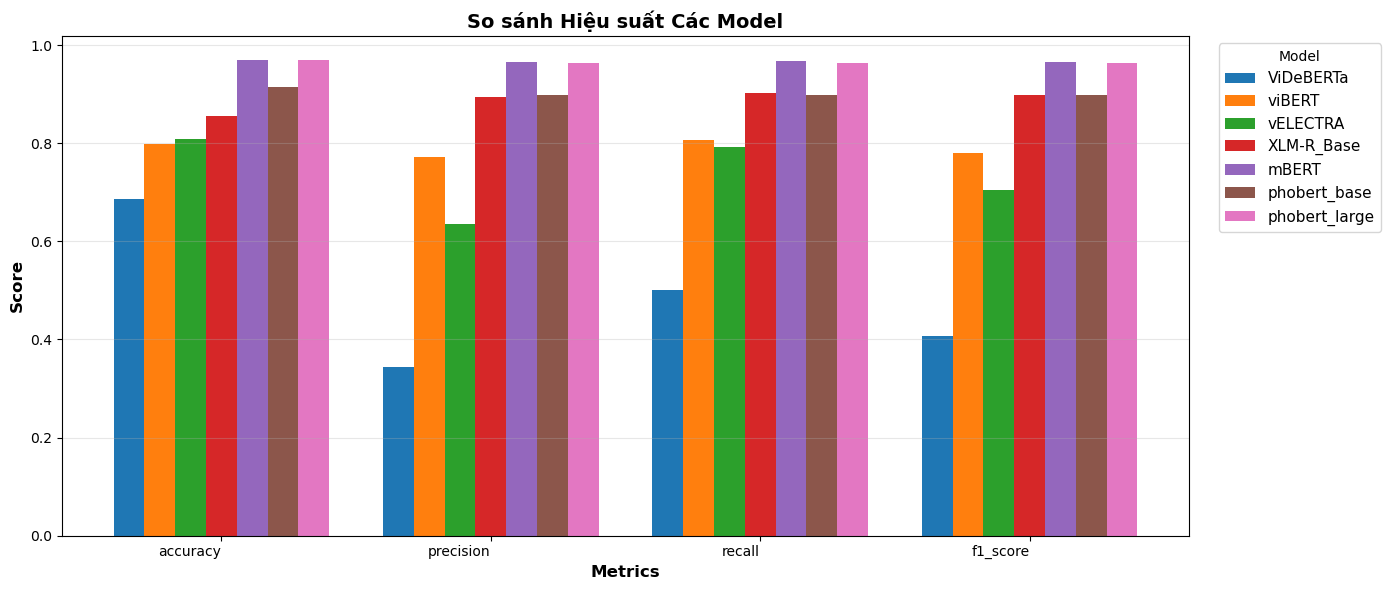

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Chuẩn bị dữ liệu cho biểu đồ
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
models = df_results['model'].tolist()
n_models = len(models)

# Thiết lập vị trí trên trục X và độ rộng của từng cột
x = np.arange(len(metrics))  # Vị trí gốc của các metrics
width = 0.8 / n_models       # Chia đều không gian 0.8 cho số lượng model

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(14, 6)) # Tăng chiều rộng một chút để chứa các cột thoải mái hơn

# Vẽ các cột cho từng model
for i, model in enumerate(models):
    # Tính toán độ lệch (offset) để các cột không bị đè lên nhau
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(x + offset, df_results.loc[i, metrics], width, label=model)

# Cấu hình biểu đồ
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('So sánh Hiệu suất Các Model', fontsize=14, fontweight='bold')

# Cập nhật nhãn trục X để hiển thị đúng vị trí các chỉ số đánh giá
ax.set_xticks(x)
ax.set_xticklabels(metrics, ha='right')

# Đặt legend ở góc trên cùng bên ngoài đồ thị
ax.legend(title='Model', fontsize=11, bbox_to_anchor=(1.02, 1), loc='upper left')

# Cấu hình lưới (đối với biểu đồ cột thường chỉ cần lưới ngang)
ax.grid(axis='y', alpha=0.3)
#ax.set_ylim([0, 1.1]) # Nới rộng trục y một chút để cột không chạm nóc

plt.tight_layout()
plt.show()

# Check Sơ Lược

In [3]:
# Load dataset raw để kiểm tra
raw_df = pd.read_csv('raw/clickbait_dataset_vietnamese.csv')

# Số lượng rows có 'lead_paragraph' rỗng (NaN hoặc chỉ chứa khoảng trắng)
empty_lead_count = (raw_df['lead_paragraph'].fillna('').astype(str).str.strip() == '').sum()

# Số lượng rows có title trùng với 'lead_paragraph' (sau khi chuẩn hóa strip)
title_clean = raw_df['title'].fillna('').astype(str).str.strip()
lead_clean = raw_df['lead_paragraph'].fillna('').astype(str).str.strip()
same_count = (title_clean == lead_clean).sum()

print(f"Số lượng rows có 'lead_paragraph' rỗng: {empty_lead_count}")
print(f"Số lượng rows có title trùng với 'lead_paragraph': {same_count}")


Số lượng rows có 'lead_paragraph' rỗng: 3
Số lượng rows có title trùng với 'lead_paragraph': 7


In [8]:
raw_df[raw_df['lead_paragraph'].fillna('').astype(str).str.strip() == '']

,id,url,title,lead_paragraph,category,publish_datetime,source,thumbnail_url,label
1617,article_2299,https://thanhnien.vn/nho-truong-sa-tho-cua-hoa...,Nhớ Trường Sa - Thơ của Hoàng Thụy Anh,NaN,Văn hóa & Nghệ thuật,2025-06-22T08:00:00+07:00,Thanh Niên,data/images/article_2299_image.png,non-clickbait
2894,article_1821,https://camnangtuyensinh.thanhnien.vn,Thời sự,NaN,Other,"Thứ Ba, 11/4/2023",Thanh Niên,data/images/article_1821_image.png,clickbait
3163,article_2870,https://thanhnien.vn/the-thao/bong-da-thanh-ni...,Top đội bóng,NaN,Chính trị & An ninh,NaN,Thanh Niên,data/images/article_2870_image.png,clickbait


In [9]:
raw_df[title_clean == lead_clean]

,id,url,title,lead_paragraph,category,publish_datetime,source,thumbnail_url,label
615,article_0790,https://baomoi.com/trao-huy-hieu-80-nam-tuoi-d...,Trao Huy hiệu 80 năm tuổi Đảng tặng đảng viên ...,Trao Huy hiệu 80 năm tuổi Đảng tặng đảng viên ...,Tin tức tổng hợp,2025-06-23T06:27:00.000Z,Báo Mới,data/images/article_0790_image.png,non-clickbait
821,article_1067,https://baomoi.com/gin-giu-phat-huy-gia-tri-va...,"Gìn giữ, phát huy giá trị văn hóa truyền thống...","Gìn giữ, phát huy giá trị văn hóa truyền thống...",Văn hóa & Nghệ thuật,2025-06-23T06:33:00.000Z,Báo Mới,data/images/article_1067_image.png,non-clickbait
1400,article_1931,https://baomoi.com/160-tay-vot-tranh-tai-tai-g...,160 tay vợt tranh tài tại Giải bóng bàn các nh...,160 tay vợt tranh tài tại Giải bóng bàn các nh...,Thể thao,2025-06-23T07:41:00.000Z,Báo Mới,data/images/article_1931_image.png,non-clickbait
1717,article_2456,https://baomoi.com/quy-tin-dung-nhan-dan-xa-do...,"Quỹ tín dụng nhân dân xã Đồng Văn, huyện Yên L...","Quỹ tín dụng nhân dân xã Đồng Văn, huyện Yên L...",Chính trị & An ninh,2025-06-23T09:04:52.000Z,Báo Mới,data/images/article_2456_image.png,non-clickbait
1737,article_2477,https://baomoi.com/quy-tin-dung-nhan-dan-xa-hu...,Quỹ tín dụng nhân dân xã Hưng Khánh thông báo ...,Quỹ tín dụng nhân dân xã Hưng Khánh thông báo ...,Chính trị & An ninh,2025-06-23T08:29:23.000Z,Báo Mới,data/images/article_2477_image.png,non-clickbait
1847,article_2646,https://www.saostar.vn/cong-nghe/california-fi...,California Fitness ra mắt Cali AI PT - Trợ lý ...,California Fitness ra mắt Cali AI PT - Trợ lý ...,Công nghệ & Khoa học,2025-06-19T08:00:28.796+07:00,SaoStar,data/images/article_2646_image.png,non-clickbait
3006,article_2182,https://baomoi.com/chien-si-moi-tu-tin-chinh-p...,Chiến sĩ mới tự tin chinh phục '3 tiếng nổ' - ...,Chiến sĩ mới tự tin chinh phục '3 tiếng nổ' - ...,Other,2025-06-23T08:01:07.000Z,Báo Mới,data/images/article_2182_image.png,clickbait
